In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
!pip install tqdm
from tqdm import tqdm
import time

Defaulting to user installation because normal site-packages is not writeable


In [2]:
data = pd.read_csv('data/dataset_malware.csv').drop(['Name'], axis=1)

le = LabelEncoder()
for column in data: data[column] = le.fit_transform(data[column])

features = data.drop(['Malware'], axis=1)
labels = data['Malware']

train_features,test_features,train_labels,test_labels = train_test_split(features,labels,test_size = 0.2)

model_classes = [LogisticRegression, DecisionTreeClassifier, RandomForestClassifier]
models = []
for model in tqdm(model_classes):    
    classifier = model()

    start_time = time.time()
    classifier = classifier.fit(train_features, train_labels)
    train_time = time.time() - start_time

    start_time = time.time()
    predicted_labels = classifier.predict(test_features)
    predict_time = time.time() - start_time

    accuracy = accuracy_score(test_labels, predicted_labels)

    models.append({
        'model_name': model.__name__,
        'model': classifier,
        'predictions': predicted_labels,
        'accuracy': accuracy,
        'train_time': train_time,
        'predict_time_total': predict_time,
        'predict_time_single_in_milliseconds': predict_time / len(test_features) * 1000,
        'predict_throughtput_per_second': len(test_features) / predict_time,
    })

  0%|          | 0/3 [00:00<?, ?it/s]/home/hp/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
100%|██████████| 3/3 [00:12<00:00,  4.14s/it]


In [11]:
target = 'LogisticRegression'  # Change this to the model you want to visualize
final_model = next(item['model'] for item in models if item['model_name'] == target)

!pip install eli5
import eli5
eli5.show_weights(final_model, feature_names=list(train_features.columns.tolist()), top=20)

Defaulting to user installation because normal site-packages is not writeable


Weight?,Feature
+0.011,SectionMaxChar
+0.006,BaseOfCode
+0.006,SizeOfHeaders
+0.006,e_lfanew
+0.004,SizeOfStackReserve
+0.004,MinorLinkerVersion
+0.003,e_maxalloc
+0.003,SizeOfInitializedData
+0.003,SizeOfHeapReserve
+0.003,SizeOfUninitializedData


In [13]:
target = 'RandomForestClassifier'  # Change this to the model you want to visualize
final_model = next(item['model'] for item in models if item['model_name'] == target)

final_model.feature_importances_

array([0.00000000e+00, 3.14062028e-03, 1.35630001e-03, 3.55190385e-05,
       8.47012520e-04, 2.11727657e-03, 3.14284618e-03, 5.38749465e-06,
       1.53352520e-03, 1.95269782e-05, 2.25928552e-04, 8.38128341e-06,
       1.02482331e-04, 2.32831096e-03, 1.75980216e-04, 3.20461114e-04,
       9.37822444e-03, 6.91299112e-04, 2.60225296e-03, 6.43735461e-02,
       1.17097297e-04, 2.11707390e-04, 9.98595918e-04, 5.85929219e-02,
       1.77001230e-03, 6.64864818e-02, 1.91876619e-03, 5.00795602e-03,
       2.45254161e-02, 6.01950369e-04, 8.84340111e-03, 2.59911774e-03,
       2.51724076e-02, 5.55482886e-03, 1.62705150e-03, 7.43339137e-02,
       1.02320090e-01, 1.33330599e-02, 7.64636002e-02, 8.67171784e-02,
       3.95240108e-02, 9.56821046e-03, 1.25586277e-02, 5.64151726e-03,
       4.43909707e-02, 3.43062553e-02, 5.28302984e-02, 7.72010166e-04,
       2.48163629e-03, 1.01914515e-03, 1.08932510e-04, 1.18944078e-05,
       4.04583972e-03, 5.04239624e-05, 2.93331327e-03, 1.20363121e-02,
      

/home/hp/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


<Axes: title={'center': 'Feature Importance'}>

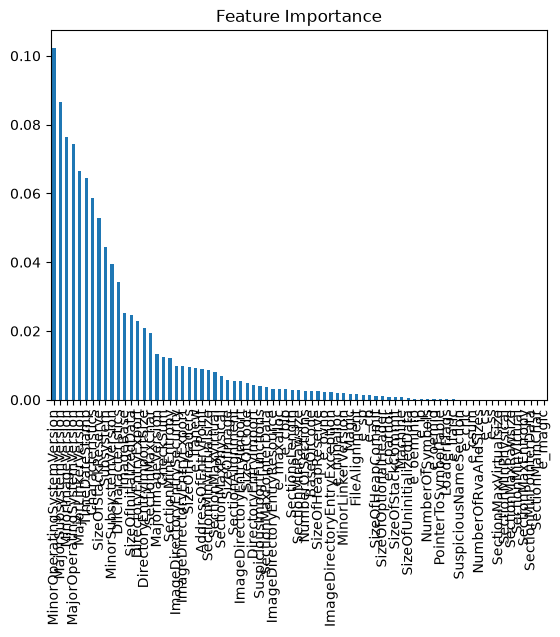

In [23]:
import pandas as pd

feature_importance = pd.Series(
    final_model.feature_importances_,
    index=train_features.columns
).sort_values(ascending=False)

feature_importance.plot(kind='bar', title='Feature Importance')

# À faire : 
1. Répondez à cette question : Que se passerais-t-il si on enlève les colonnes à importance nulle? Comparez le avant et après sur performance, temps d'entrainement, temps de prédiction, et besoin en colonnes. 

2. Si oui, jusqu'où peut-on aller? Combien peux-t-on enlever de colonnes (ainsi que lesquelles et pourquoi) et garantir de rester à 99% ?